# EXPLORAÇÃO DE DADOS

## Importando bibliotecas 

In [1]:
import pandas as pd
from pathlib import Path
from ydata_profiling import ProfileReport
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

## Funções

In [2]:
def parse_hhmm(value) -> int | None:
    """Converte inteiro HHMM para minutos após meia-noite. Ex: 5 -> 5, 1430 -> 870"""
    if pd.isna(value):
        return None
    val = int(value)
    return (val // 100) * 60 + (val % 100)


def classify_delay(minutes) -> str | None:
    if pd.isna(minutes):
        return None
    if minutes > 0:
        return "atrasado"
    return "nao_atrasado"

## Definindo os caminhos de importação de dados

In [3]:
input = Path("./data/input")
airlines_path = Path(input, "airlines.csv")
airports_path = Path(input, "airports.csv")
flights_path = Path(input, "flights.csv")

## Leitura das bases de dados em DataFrames Pandas

In [4]:
airlines = pd.read_csv(airlines_path)
airports = pd.read_csv(airports_path)
flights = pd.read_csv(flights_path, engine="pyarrow")

## Exploração do DataFrame flights

In [5]:
flights.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   YEAR                 5819079 non-null  int64  
 1   MONTH                5819079 non-null  int64  
 2   DAY                  5819079 non-null  int64  
 3   DAY_OF_WEEK          5819079 non-null  int64  
 4   AIRLINE              5819079 non-null  object 
 5   FLIGHT_NUMBER        5819079 non-null  int64  
 6   TAIL_NUMBER          5804358 non-null  object 
 7   ORIGIN_AIRPORT       5819079 non-null  object 
 8   DESTINATION_AIRPORT  5819079 non-null  object 
 9   SCHEDULED_DEPARTURE  5819079 non-null  int64  
 10  DEPARTURE_TIME       5732926 non-null  float64
 11  DEPARTURE_DELAY      5732926 non-null  float64
 12  TAXI_OUT             5730032 non-null  float64
 13  WHEELS_OFF           5730032 non-null  float64
 14  SCHEDULED_TIME       5819073 non-null  float64
 15

Conclusão:
 - As colunas possuem tipagem adequadas e sem ajustes necessários.

## Verificando quais colunas possuem nulos e quais as porcentagem de nulos

In [6]:
flights.isnull().mean().round(4) * 100

YEAR                    0.00
MONTH                   0.00
DAY                     0.00
DAY_OF_WEEK             0.00
AIRLINE                 0.00
FLIGHT_NUMBER           0.00
TAIL_NUMBER             0.25
ORIGIN_AIRPORT          0.00
DESTINATION_AIRPORT     0.00
SCHEDULED_DEPARTURE     0.00
DEPARTURE_TIME          1.48
DEPARTURE_DELAY         1.48
TAXI_OUT                1.53
WHEELS_OFF              1.53
SCHEDULED_TIME          0.00
ELAPSED_TIME            1.81
AIR_TIME                1.81
DISTANCE                0.00
WHEELS_ON               1.59
TAXI_IN                 1.59
SCHEDULED_ARRIVAL       0.00
ARRIVAL_TIME            1.59
ARRIVAL_DELAY           1.81
DIVERTED                0.00
CANCELLED               0.00
CANCELLATION_REASON    98.46
AIR_SYSTEM_DELAY       81.72
SECURITY_DELAY         81.72
AIRLINE_DELAY          81.72
LATE_AIRCRAFT_DELAY    81.72
WEATHER_DELAY          81.72
dtype: float64

Conclusão: 
Não podemos utilizar as features abaixo pela grande quantidade de nulos
 - AIR_SYSTEM_DELAY
 - SECURITY_DELAY
 - AIRLINE_DELAY
 - LATE_AIRCRAFT_DELAY
 - WEATHER_DELAY

A porcentagem de nulos é baixa e provavelmente, a retirada de todos os nulos da base não influenciará negativamente.

## Limpeza inicial da base flights

Seleção de colunas e retirada de linhas com nulos

In [7]:
flighs_limpa = flights[
    [
        "YEAR",
        "MONTH",
        "DAY",
        "DAY_OF_WEEK",
        "AIRLINE",
        "FLIGHT_NUMBER",
        "TAIL_NUMBER",
        "ORIGIN_AIRPORT",
        "DESTINATION_AIRPORT",
        "SCHEDULED_DEPARTURE",
        "DEPARTURE_TIME",
        "DEPARTURE_DELAY",
        "TAXI_OUT",
        "WHEELS_OFF",
        "SCHEDULED_TIME",
        "ELAPSED_TIME",
        "AIR_TIME",
        "DISTANCE",
        "WHEELS_ON",
        "TAXI_IN",
        "SCHEDULED_ARRIVAL",
        "ARRIVAL_TIME",
        "ARRIVAL_DELAY",
        "DIVERTED",
    ]
].dropna(how="any")

Confirmando ausência de nulos

In [8]:
flighs_limpa.isnull().sum().sum()

np.int64(0)

Confirmando colunas que permaneceram

In [9]:
flighs_limpa.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED'],
      dtype='object')

## Tratamento e categorização

Criando colunas importantes para avaliação:
 - TOTAL_DELAY = Soma de atrasos de partida e atraso de pouso
 - CAT_TOTAL_DELAY = Categorização do atraso total - negativo é adiantado, positivo atrasado.
 - CAT_ARRIVAL_DELAY = Categorização do atraso chegada - negativo é adiantado, positivo atrasado.
 - CAT_DEPARTURE_DELAY = Categorização do atraso partida - negativo é adiantado, positivo atrasado.

In [10]:
flights_tratada = flighs_limpa.copy()

### Calculando taxa de atraso histórico de aeroportos

In [11]:
taxa_partida_origem_airline = flights_tratada.groupby(["ORIGIN_AIRPORT", "AIRLINE"])[
    "DEPARTURE_DELAY"
].apply(lambda x: (x > 0).mean())


flights_tratada["TAXA_ATRASO_PARTIDA_ORIGEM_AIRLINE"] = flights_tratada.set_index(
    ["ORIGIN_AIRPORT", "AIRLINE"]
).index.map(taxa_partida_origem_airline)  # type: ignore

In [12]:
taxa_chegada_origem_airline = flights_tratada.groupby(["ORIGIN_AIRPORT", "AIRLINE"])[
    "ARRIVAL_DELAY"
].apply(lambda x: (x > 0).mean())

flights_tratada["TAXA_ATRASO_CHEGADA_ORIGEM_AIRLINE"] = flights_tratada.set_index(
    ["ORIGIN_AIRPORT", "AIRLINE"]
).index.map(taxa_chegada_origem_airline)  # type: ignore


### Classificação de atrasos

In [13]:
colunas_atrasos = ["ARRIVAL_DELAY", "DEPARTURE_DELAY"]

In [14]:
for col in colunas_atrasos:
    flights_tratada[f"CAT_{col}"] = flights_tratada[col].apply(classify_delay)

### Padronização das colunas de horários para minutos após meia-noite

In [15]:
colunas_tempo = [
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_TIME",
    "WHEELS_OFF",
    "WHEELS_ON",
    "SCHEDULED_ARRIVAL",
    "ARRIVAL_TIME",
]

In [16]:
for col in colunas_tempo:
    flights_tratada[col] = flights_tratada[col].apply(parse_hhmm).astype("int64")

In [17]:
flights_tratada.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5714008 entries, 0 to 5819078
Data columns (total 28 columns):
 #   Column                              Dtype  
---  ------                              -----  
 0   YEAR                                int64  
 1   MONTH                               int64  
 2   DAY                                 int64  
 3   DAY_OF_WEEK                         int64  
 4   AIRLINE                             object 
 5   FLIGHT_NUMBER                       int64  
 6   TAIL_NUMBER                         object 
 7   ORIGIN_AIRPORT                      object 
 8   DESTINATION_AIRPORT                 object 
 9   SCHEDULED_DEPARTURE                 int64  
 10  DEPARTURE_TIME                      int64  
 11  DEPARTURE_DELAY                     float64
 12  TAXI_OUT                            float64
 13  WHEELS_OFF                          int64  
 14  SCHEDULED_TIME                      float64
 15  ELAPSED_TIME                        float64
 16  AIR_T

## Heatmap correlação

<Axes: >

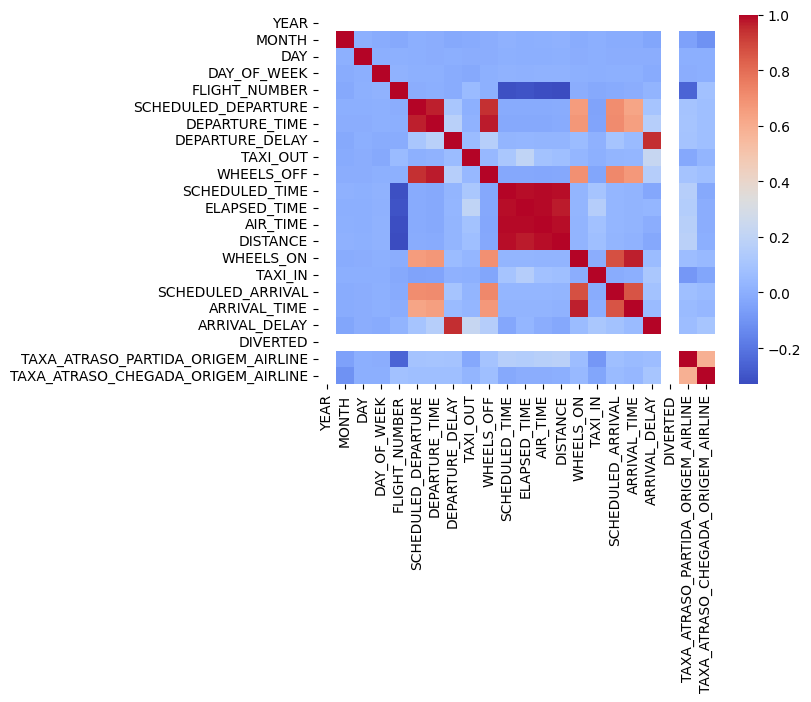

In [18]:
corr = flights_tratada.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")

In [19]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
    .query("correlation.abs() > 0.85")
    .sort_values("correlation", ascending=False)
)

high_corr.sort_values(by="feature_1")

,feature_1,feature_2,correlation
154,AIR_TIME,DISTANCE,0.985643
109,DEPARTURE_DELAY,ARRIVAL_DELAY,0.944672
87,DEPARTURE_TIME,WHEELS_OFF,0.972022
145,ELAPSED_TIME,AIR_TIME,0.990033
146,ELAPSED_TIME,DISTANCE,0.973696
180,SCHEDULED_ARRIVAL,ARRIVAL_TIME,0.863032
70,SCHEDULED_DEPARTURE,DEPARTURE_TIME,0.964126
73,SCHEDULED_DEPARTURE,WHEELS_OFF,0.937972
136,SCHEDULED_TIME,AIR_TIME,0.990749
135,SCHEDULED_TIME,ELAPSED_TIME,0.985260


## Visualizações EDA — Insights sobre atrasos

### Taxa de atraso por mês

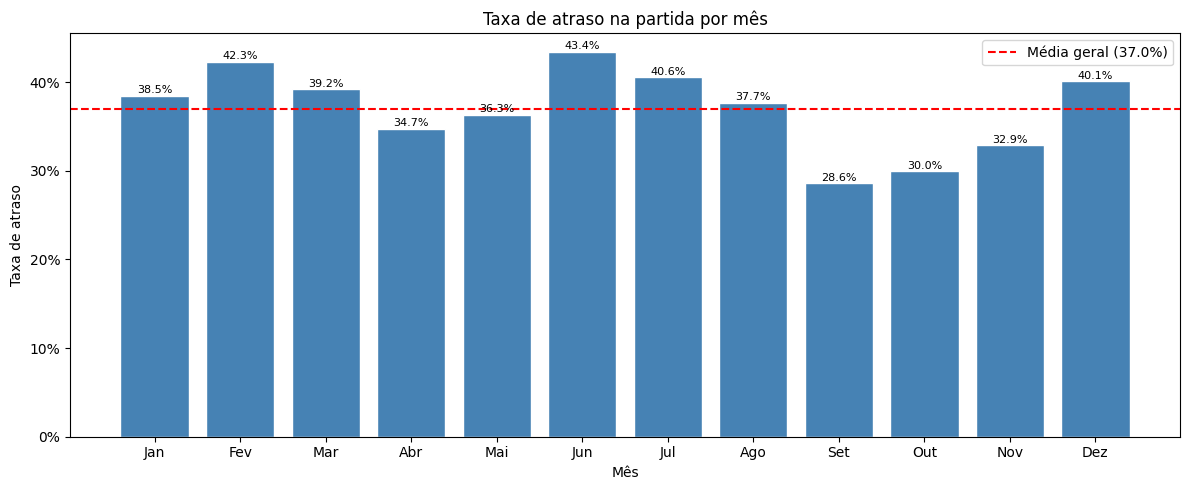

In [20]:
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

taxa_mes = flights_tratada.groupby('MONTH')['DEPARTURE_DELAY'].apply(lambda x: (x > 0).mean())

plt.figure(figsize=(12, 5))
bars = plt.bar(meses, taxa_mes.values, color='steelblue', edgecolor='white')
plt.axhline(taxa_mes.mean(), color='red', linestyle='--', label=f'Média geral ({taxa_mes.mean():.1%})')
plt.title('Taxa de atraso na partida por mês')
plt.ylabel('Taxa de atraso')
plt.xlabel('Mês')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar, val in zip(bars, taxa_mes.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f'{val:.1%}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('data/output/eda_atraso_por_mes.png', dpi=150, bbox_inches='tight')
plt.show()

### Taxa de atraso por dia da semana

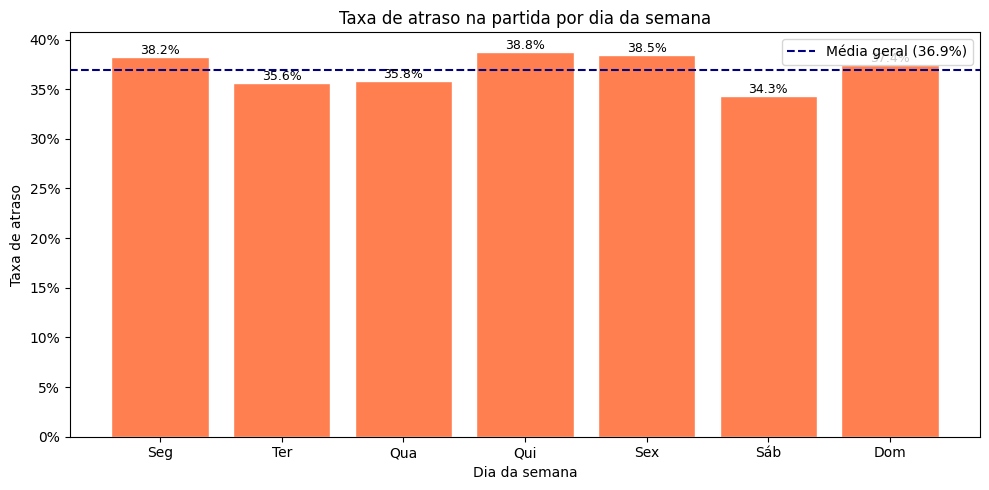

In [21]:
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

taxa_dia = flights_tratada.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].apply(lambda x: (x > 0).mean())

plt.figure(figsize=(10, 5))
bars = plt.bar(dias, taxa_dia.values, color='coral', edgecolor='white')
plt.axhline(taxa_dia.mean(), color='navy', linestyle='--', label=f'Média geral ({taxa_dia.mean():.1%})')
plt.title('Taxa de atraso na partida por dia da semana')
plt.ylabel('Taxa de atraso')
plt.xlabel('Dia da semana')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar, val in zip(bars, taxa_dia.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f'{val:.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('data/output/eda_atraso_por_dia.png', dpi=150, bbox_inches='tight')
plt.show()

### Top 10 companhias com maior taxa de atraso

In [22]:
taxa_airline = (
    flights_tratada.groupby('AIRLINE')['DEPARTURE_DELAY']
    .apply(lambda x: (x > 0).mean())
    .sort_values(ascending=True)
)

# Mapeia código para nome completo
taxa_airline.index = taxa_airline.index.map(
    airlines.set_index('IATA_CODE')['AIRLINE'].to_dict()
).fillna(taxa_airline.index)

plt.figure(figsize=(10, 6))
bars = plt.barh(taxa_airline.index, taxa_airline.values, color='steelblue', edgecolor='white')
plt.axvline(taxa_airline.mean(), color='red', linestyle='--', label=f'Média ({taxa_airline.mean():.1%})')
plt.title('Taxa de atraso na partida por companhia aérea')
plt.xlabel('Taxa de atraso')
plt.legend()
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
for bar, val in zip(bars, taxa_airline.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height() / 2, f'{val:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('data/output/eda_atraso_por_airline.png', dpi=150, bbox_inches='tight')
plt.show()

TypeError: 'value' must be a scalar, passed: Index

### Top 10 aeroportos com maior taxa de atraso

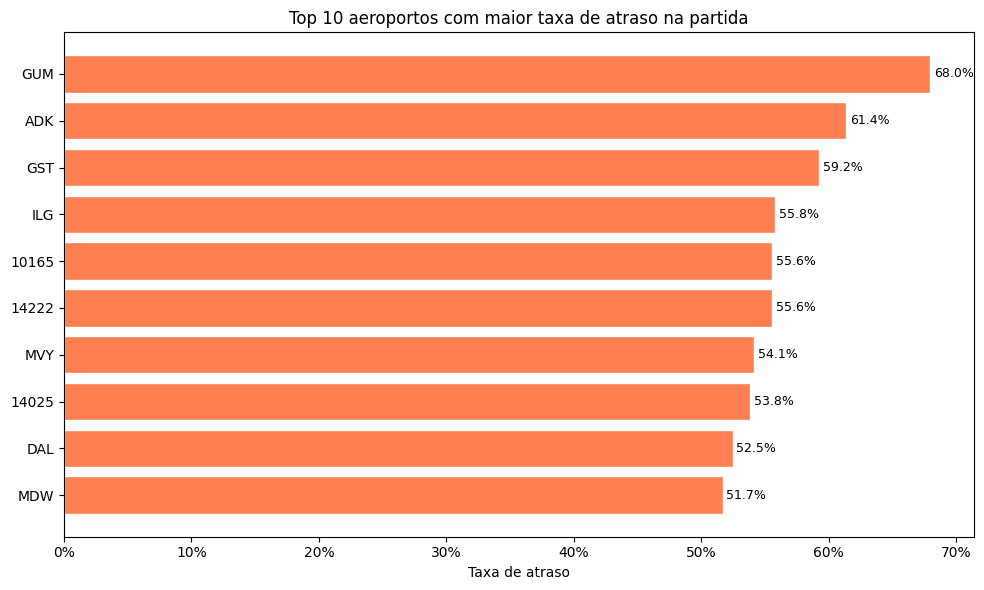

In [23]:
taxa_origem = (
    flights_tratada.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY']
    .apply(lambda x: (x > 0).mean())
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
bars = plt.barh(taxa_origem.index, taxa_origem.values, color='coral', edgecolor='white')
plt.title('Top 10 aeroportos com maior taxa de atraso na partida')
plt.xlabel('Taxa de atraso')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
for bar, val in zip(bars, taxa_origem.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height() / 2, f'{val:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('data/output/eda_top10_aeroportos.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribuição dos atrasos de partida por período do dia

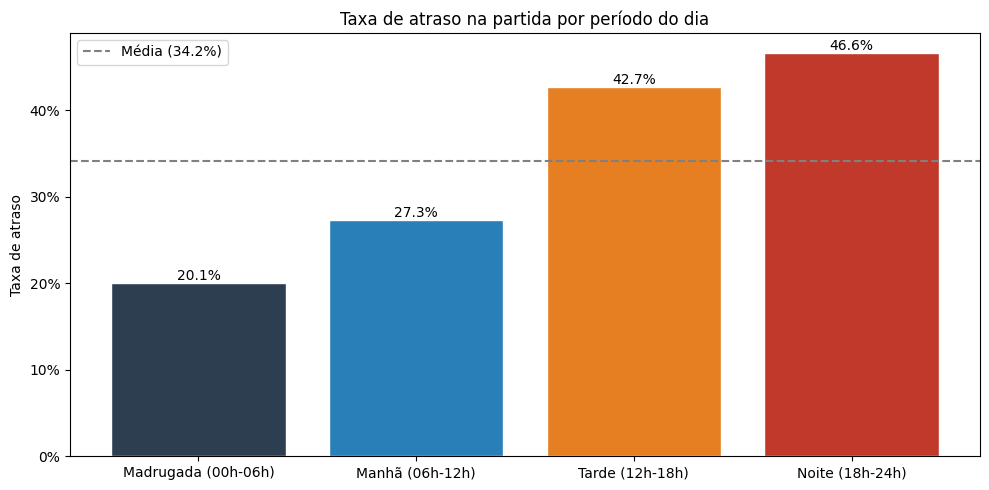

In [24]:
def periodo_do_dia(minutos):
    if minutos < 360:  return 'Madrugada (00h-06h)'
    if minutos < 720:  return 'Manhã (06h-12h)'
    if minutos < 1080: return 'Tarde (12h-18h)'
    return 'Noite (18h-24h)'

flights_tratada['PERIODO_PARTIDA'] = flights_tratada['SCHEDULED_DEPARTURE'].apply(periodo_do_dia)

ordem = ['Madrugada (00h-06h)', 'Manhã (06h-12h)', 'Tarde (12h-18h)', 'Noite (18h-24h)']
taxa_periodo = (
    flights_tratada.groupby('PERIODO_PARTIDA')['DEPARTURE_DELAY']
    .apply(lambda x: (x > 0).mean())
    .reindex(ordem)
)

plt.figure(figsize=(10, 5))
bars = plt.bar(taxa_periodo.index, taxa_periodo.values, color=['#2c3e50', '#2980b9', '#e67e22', '#c0392b'], edgecolor='white')
plt.axhline(taxa_periodo.mean(), color='gray', linestyle='--', label=f'Média ({taxa_periodo.mean():.1%})')
plt.title('Taxa de atraso na partida por período do dia')
plt.ylabel('Taxa de atraso')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar, val in zip(bars, taxa_periodo.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f'{val:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('data/output/eda_atraso_por_periodo.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualização para insights com Ydata-profilling

In [25]:
# profile = ProfileReport(flights_tratada)
# profile.to_file("data/output/visualizacao.html")

Colunas à remover:

 - YEAR é constante
 - DIVERTED é constante e 0
 - Retirando features derivadas para evitar dataleakege
 - As colunas de horário real de chegada, de partida e de tempo total de voo são altamente relacionadas com os horários programados e são consequências dos atrasos (as diferenças para os horários programados), por isso, irei retirá-las inicialmente.
 

In [26]:
flights_tratada_drop_cols = flights_tratada.drop(
    columns=[
        "YEAR",
        "DIVERTED",
        "AIR_TIME",
        "DEPARTURE_TIME",
        "ARRIVAL_TIME",
        "ELAPSED_TIME",
        "WHEELS_ON",
        "TAXI_IN",
        "DEPARTURE_DELAY",
        "ARRIVAL_DELAY",
        "TAXI_OUT",
        "WHEELS_OFF",
        "CAT_ARRIVAL_DELAY",
        "TAXA_ATRASO_CHEGADA_ORIGEM_AIRLINE",
    ]
)


In [27]:
flights_tratada_drop_cols.shape

(5714008, 15)

## Balanceamento do df

In [28]:
atrasos_partida = flights_tratada_drop_cols.query("CAT_DEPARTURE_DELAY == 'atrasado'")
sem_atraso_partida = flights_tratada_drop_cols.query(
    "CAT_DEPARTURE_DELAY != 'atrasado'"
)

sem_atraso_partida = sem_atraso_partida.sample(n=len(atrasos_partida), random_state=42)

df_partida = (
    pd.concat([atrasos_partida, sem_atraso_partida])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

In [29]:
df_partida["CAT_DEPARTURE_DELAY"].value_counts()

CAT_DEPARTURE_DELAY
atrasado        2115049
nao_atrasado    2115049
Name: count, dtype: int64

In [30]:
df_partida

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,TAXA_ATRASO_PARTIDA_ORIGEM_AIRLINE,CAT_DEPARTURE_DELAY,PERIODO_PARTIDA
0,3,13,5,AA,1030,N501AA,JAX,DFW,909,171.0,918,1020,0.293408,atrasado,Tarde (12h-18h)
1,4,5,7,WN,468,N653SW,BOS,BWI,1215,90.0,369,1305,0.447056,atrasado,Noite (18h-24h)
2,10,18,7,AA,477,N150UW,14771,14107,945,118.0,651,1063,0.278206,nao_atrasado,Tarde (12h-18h)
3,12,28,1,AA,1439,N3JCAA,DFW,BNA,845,104.0,631,949,0.428015,atrasado,Tarde (12h-18h)
4,6,30,2,WN,41,N657SW,HOU,CRP,1090,45.0,187,1135,0.506018,atrasado,Noite (18h-24h)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4230093,9,6,7,DL,1382,N939DN,DEN,ATL,710,175.0,1199,1005,0.364671,nao_atrasado,Manhã (06h-12h)
4230094,7,7,2,WN,214,N765SW,LAX,PHX,475,80.0,370,555,0.576281,atrasado,Manhã (06h-12h)
4230095,9,17,4,UA,1214,N77871,IAH,LAX,688,217.0,1379,785,0.612427,atrasado,Manhã (06h-12h)
4230096,11,24,2,WN,1011,N208WN,MDW,PHX,610,235.0,1444,785,0.529401,nao_atrasado,Manhã (06h-12h)


In [31]:
df_partida.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE',
       'SCHEDULED_ARRIVAL', 'TAXA_ATRASO_PARTIDA_ORIGEM_AIRLINE',
       'CAT_DEPARTURE_DELAY', 'PERIODO_PARTIDA'],
      dtype='object')

# MODELO SUPERVISIONADO

In [32]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [33]:
df_encoded = df_partida.copy()

In [34]:
le = LabelEncoder()
encoders = {}
for col in df_encoded.select_dtypes(include="object").columns:
    encoders[col] = LabelEncoder()
    df_encoded[col] = encoders[col].fit_transform(df_encoded[col].astype(str))

dict(
    zip(
        encoders["CAT_DEPARTURE_DELAY"].transform(
            encoders["CAT_DEPARTURE_DELAY"].classes_
        ),
        encoders["CAT_DEPARTURE_DELAY"].classes_,
    )
)

{np.int64(0): 'atrasado', np.int64(1): 'nao_atrasado'}

In [35]:
x = df_encoded[
    [
        "MONTH",
        "DAY",
        "DAY_OF_WEEK",
        "AIRLINE",
        "FLIGHT_NUMBER",
        "TAIL_NUMBER",
        "ORIGIN_AIRPORT",
        "DESTINATION_AIRPORT",
        "SCHEDULED_DEPARTURE",
        "SCHEDULED_TIME",
        "DISTANCE",
    ]
]

y = df_encoded[["CAT_DEPARTURE_DELAY"]]

In [36]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

## Árvore de decisão

In [37]:
modelo = DecisionTreeClassifier()
modelo.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

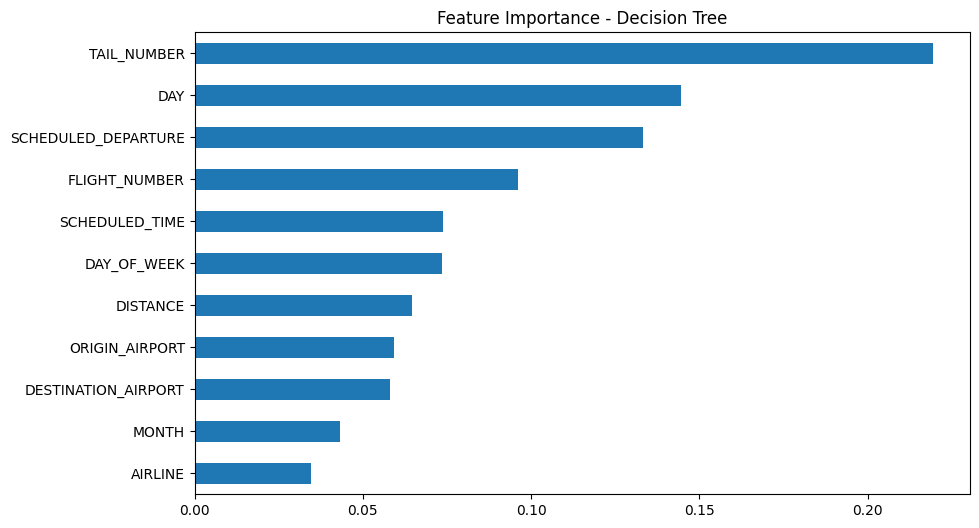

In [38]:
importancias = pd.Series(modelo.feature_importances_, index=x_train.columns)
importancias.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance - Decision Tree')
plt.show()

In [39]:
y_pred = modelo.predict(x_test)

Métrica:	O que significa
 - precision	dos que o modelo disse "atrasado", quantos realmente eram
 - recall	dos que realmente eram "atrasado", quantos o modelo acertou
 - f1-score	média harmônica entre precision e recall
 - support	quantas amostras de cada classe existem no teste

In [43]:
print(classification_report(y_test, y_pred, target_names=["atrasado", "nao_atrasado"]))# type: ignore

              precision    recall  f1-score   support

    atrasado       0.59      0.59      0.59    634228
nao_atrasado       0.59      0.59      0.59    634802

    accuracy                           0.59   1269030
   macro avg       0.59      0.59      0.59   1269030
weighted avg       0.59      0.59      0.59   1269030



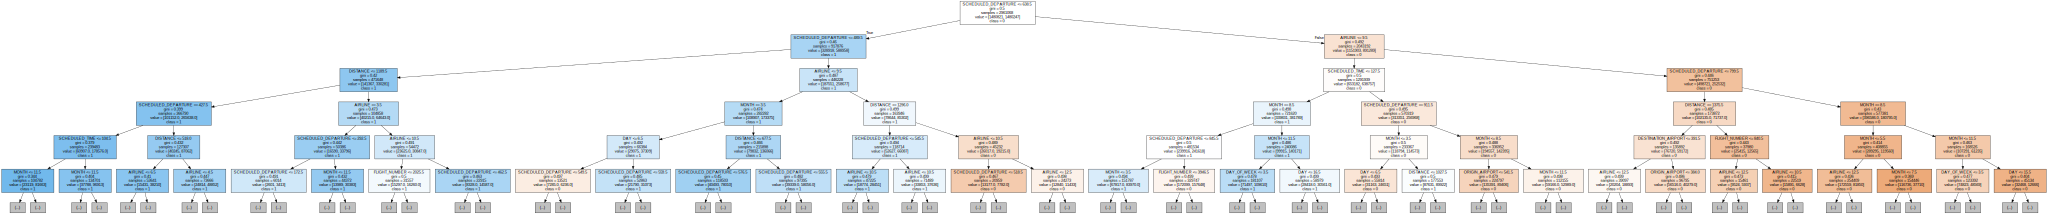

In [44]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    modelo,
    feature_names=x_train.columns,
    class_names=[str(c) for c in modelo.classes_],
    filled=True,
    max_depth=5,
)
graphviz.Source(dot_data)


## XGBoost

In [45]:
from xgboost import XGBClassifier

In [46]:
modelo_xgb = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=42
)

In [47]:
modelo_xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [48]:
y_pred_xgb = modelo_xgb.predict(x_test)

Métrica:	O que significa
 - precision	dos que o modelo disse "atrasado", quantos realmente eram
 - recall	dos que realmente eram "atrasado", quantos o modelo acertou
 - f1-score	média harmônica entre precision e recall
 - support	quantas amostras de cada classe existem no teste

In [49]:
print(classification_report(y_test, y_pred_xgb, target_names=["atrasado", "nao_atrasado"]))

              precision    recall  f1-score   support

    atrasado       0.65      0.65      0.65    634228
nao_atrasado       0.65      0.65      0.65    634802

    accuracy                           0.65   1269030
   macro avg       0.65      0.65      0.65   1269030
weighted avg       0.65      0.65      0.65   1269030



<Figure size 1000x600 with 0 Axes>

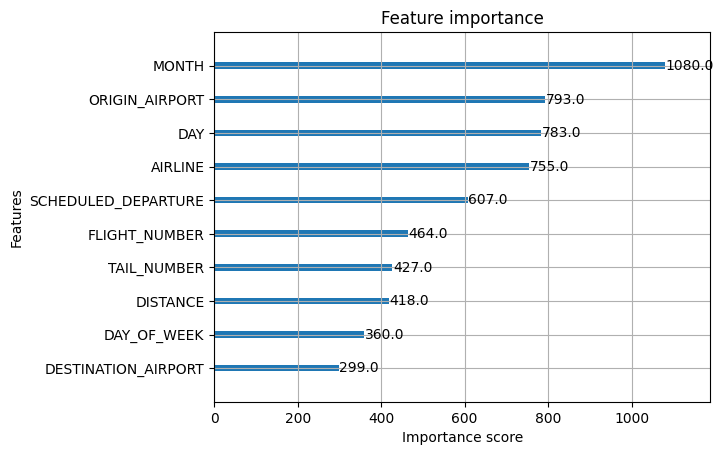

In [50]:
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(modelo_xgb, max_num_features=10)
plt.show()


## Comparação / Conclusão

O modelo de árvore de decisões teve precisão e recall de 0.59, o que indica que o modelo acerta a maioria das vezes, porém, com uma margem não muito significativa. O modelo XGBoost acerta mais vezes 0.65 de precisão e recall trazendo maior confiabiliade.

Um achado interessante, é que para decision tree, a feature mais importante foi Tail number (numero da aeronave), que não fez muito sentindo para mim, imaginava que as variáveis aeroporto de partida, companhia aérea e horário de partida seriam mais significativas.

Com XGBoost a variável mais importante foi o mês, fazendo sentido pensando que certos meses do ano possuem mais voos e maior change de atrasos.


Para melhorar o modelo, acrescentaria dados externos de quantidade de voos planejados para aquela hora de partida, dados de clima, dados de feriados e taxa histórica de atrasos da CIA Aérea + Aeroporto. 

Não utilizei os dados acessórios de Airline e Airport, pois eles não acrescentariam adição de features impactantes.

# Modelo não supervisionado

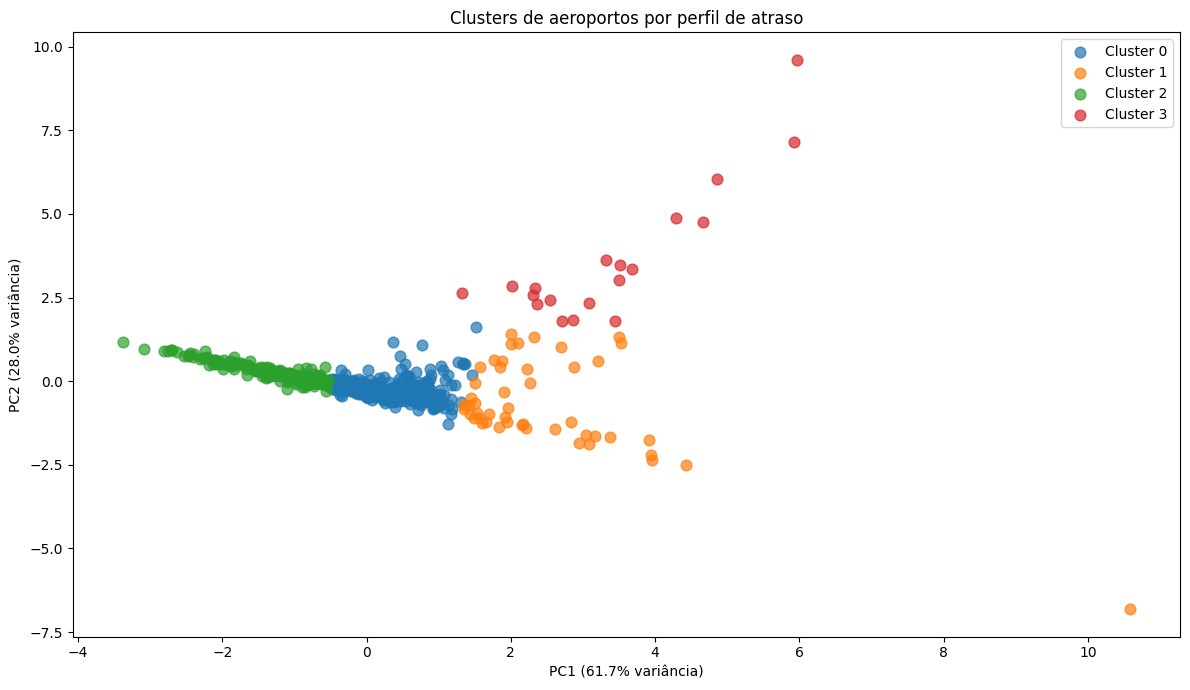

,taxa_atraso,media_atraso,total_voos
cluster,,,
0,0.28,6.67,5090.74
1,0.44,15.83,19744.04
2,0.16,0.65,657.52
3,0.39,10.30,148845.63


In [54]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

perfil = flights_tratada.groupby('ORIGIN_AIRPORT').agg(
    taxa_atraso=('DEPARTURE_DELAY', lambda x: (x > 0).mean()),
    media_atraso=('DEPARTURE_DELAY', 'mean'),
    total_voos=('DEPARTURE_DELAY', 'count')
).dropna()

scaler = StandardScaler()
perfil_scaled = scaler.fit_transform(perfil)

kmeans = KMeans(n_clusters=4, random_state=42)
perfil['cluster'] = kmeans.fit_predict(perfil_scaled)

# Plot com PCA 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(perfil_scaled)

plt.figure(figsize=(12, 7))
for cluster_id in sorted(perfil['cluster'].unique()):
    mask = perfil['cluster'] == cluster_id
    plt.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {cluster_id}', alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variância)')
plt.title('Clusters de aeroportos por perfil de atraso')
plt.legend()
plt.tight_layout()
plt.show()

# Perfil médio de cada cluster
perfil.groupby('cluster')[['taxa_atraso', 'media_atraso', 'total_voos']].mean().round(2)


In [56]:
# Perfil médio por cluster
print(perfil.groupby('cluster')[['taxa_atraso', 'media_atraso', 'total_voos']].mean().round(2))


         taxa_atraso  media_atraso  total_voos
cluster                                       
0               0.28          6.67     5090.74
1               0.44         15.83    19744.04
2               0.16          0.65      657.52
3               0.39         10.30   148845.63


In [57]:
# Top 5 aeroportos de cada cluster
for c in sorted(perfil['cluster'].unique()):
    aeroportos = perfil[perfil['cluster'] == c].sort_values('total_voos', ascending=False).head(5)
    print(f"\n--- Cluster {c} ---")
    print(aeroportos[['taxa_atraso', 'media_atraso', 'total_voos']])



--- Cluster 0 ---
                taxa_atraso  media_atraso  total_voos
ORIGIN_AIRPORT                                       
DCA                0.314548      7.939032       71579
PDX                0.295851      5.349189       46777
HNL                0.285521      2.624668       42946
MSY                0.349525      8.651442       38292
MCI                0.349210      8.370650       38106

--- Cluster 1 ---
                taxa_atraso  media_atraso  total_voos
ORIGIN_AIRPORT                                       
BWI                0.494278     13.255333       84329
MDW                0.516782     12.766283       78685
FLL                0.386732     10.616506       72580
SAN                0.383211      8.314869       69270
MIA                0.424225     12.413332       68301

--- Cluster 2 ---
                taxa_atraso  media_atraso  total_voos
ORIGIN_AIRPORT                                       
LIH                0.248212      0.457900       10487
14869              0.2138

In [59]:
# Junta com nome da cidade para facilitar interpretação
perfil_info = perfil.join(
    airports.set_index('IATA_CODE')[['CITY', 'STATE']]
)

for c in sorted(perfil_info['cluster'].unique()):
    grupo = perfil_info[perfil_info['cluster'] == c].sort_values('total_voos', ascending=False).head(5)
    print(f"\n--- Cluster {c} (taxa média: {perfil_info[perfil_info['cluster']==c]['taxa_atraso'].mean():.1%}) ---")
    print(grupo[['CITY', 'STATE', 'taxa_atraso', 'media_atraso', 'total_voos']].to_string())



--- Cluster 0 (taxa média: 28.4%) ---
                       CITY STATE  taxa_atraso  media_atraso  total_voos
ORIGIN_AIRPORT                                                          
DCA               Arlington    VA     0.314548      7.939032       71579
PDX                Portland    OR     0.295851      5.349189       46777
HNL                Honolulu    HI     0.285521      2.624668       42946
MSY             New Orleans    LA     0.349525      8.651442       38292
MCI             Kansas City    MO     0.349210      8.370650       38106

--- Cluster 1 (taxa média: 44.2%) ---
                          CITY STATE  taxa_atraso  media_atraso  total_voos
ORIGIN_AIRPORT                                                             
BWI                  Baltimore    MD     0.494278     13.255333       84329
MDW                    Chicago    IL     0.516782     12.766283       78685
FLL             Ft. Lauderdale    FL     0.386732     10.616506       72580
SAN                  San Diego 

In [60]:
rotulos = {0: 'pontual', 1: 'critico', 2: 'regional', 3: 'hub'}
perfil['perfil_aeroporto'] = perfil['cluster'].map(rotulos)